# Question 5: Yeast Protein Interactome (YPI)

We construct the yeast protein-protein interaction network using the **LC-multiple** dataset from the Yeast Interactome Database (literature-curated interactions with multiple evidence).

- **(a)** Build the network, plot degree distribution and $C(k) \times k$, visualize and highlight important proteins
- **(b)** Identify key proteins, cross-reference with essential gene data from SGD
- **(c)** Random and targeted node deletion — robustness analysis ($S$ and $\langle s \rangle$)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random
import csv
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)

---

## Part (a): Constructing the YPI Network

Loading the LC-multiple dataset — each line is a tab-separated pair of yeast ORF names representing a protein-protein interaction.

In [3]:
# Load the LC-multiple interaction data
G_ypi = nx.Graph()

with open('LC-multiple.txt', 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            G_ypi.add_edge(parts[0], parts[1])

# Remove self-loops if any
G_ypi.remove_edges_from(nx.selfloop_edges(G_ypi))

# Take largest connected component
lcc = max(nx.connected_components(G_ypi), key=len)
G_ypi = G_ypi.subgraph(lcc).copy()

n = G_ypi.number_of_nodes()
m = G_ypi.number_of_edges()
avg_k = 2 * m / n

print(f"YPI Network (LC-multiple dataset):")
print(f"  Nodes (proteins): {n}")
print(f"  Edges (interactions): {m}")
print(f"  Average degree: {avg_k:.2f}")
print(f"  Density: {nx.density(G_ypi):.5f}")

YPI Network (LC-multiple dataset):
  Nodes (proteins): 1213
  Edges (interactions): 2556
  Average degree: 4.21
  Density: 0.00348


### Degree Distribution

Plotting $P(k)$ on a log-log scale. If the network is scale-free, this should roughly follow a straight line.

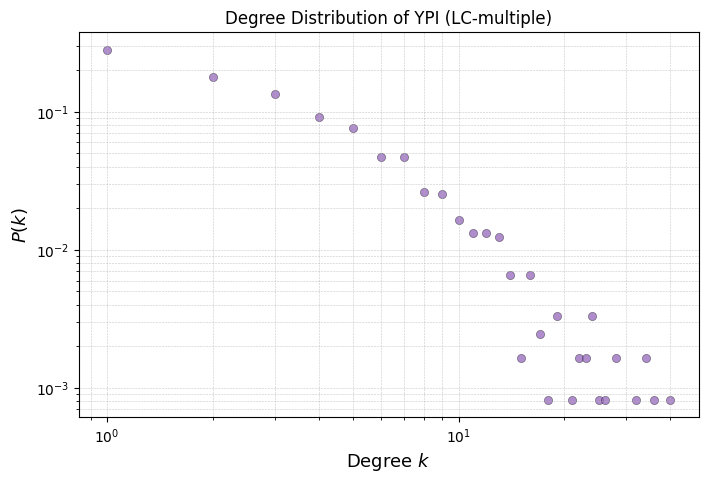

Max degree: 40, Min degree: 1
Median degree: 3


In [4]:
degrees = [d for _, d in G_ypi.degree()]
deg_counts = {}
for d in degrees:
    deg_counts[d] = deg_counts.get(d, 0) + 1

k_vals = sorted(deg_counts.keys())
p_k = [deg_counts[k] / n for k in k_vals]

plt.figure(figsize=(8, 5))
plt.scatter(k_vals, p_k, color='#9467bd', alpha=0.75, s=35,
            edgecolors='k', linewidths=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree $k$', fontsize=13)
plt.ylabel('$P(k)$', fontsize=13)
plt.title('Degree Distribution of YPI (LC-multiple)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.7)
plt.savefig('ypi_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max degree: {max(degrees)}, Min degree: {min(degrees)}")
print(f"Median degree: {np.median(degrees):.0f}")

### $C(k) \times k$ Plot

$C(k)$ is the average clustering coefficient of all nodes with degree $k$. The product $C(k) \times k$ is useful for detecting hierarchical modularity in biological networks.

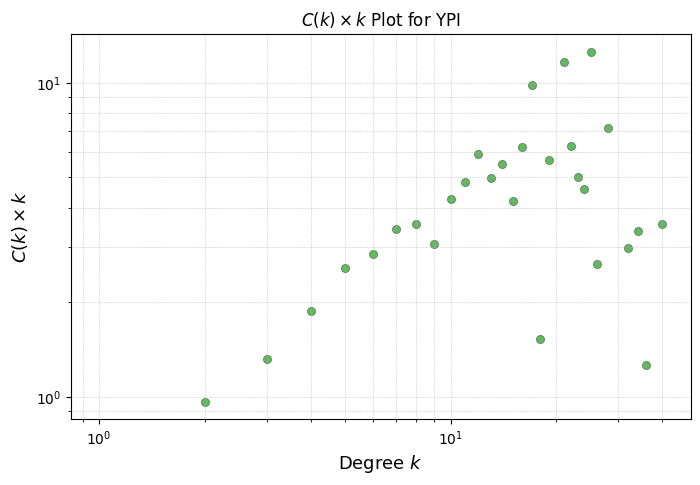

In [5]:
# Compute C(k) — average clustering coefficient for each degree k
clustering = nx.clustering(G_ypi)

# Group by degree
degree_to_cc = {}
for node in G_ypi.nodes():
    k = G_ypi.degree(node)
    if k not in degree_to_cc:
        degree_to_cc[k] = []
    degree_to_cc[k].append(clustering[node])

# Average C(k) for each degree
k_list = sorted(degree_to_cc.keys())
ck_list = [np.mean(degree_to_cc[k]) for k in k_list]
ck_times_k = [np.mean(degree_to_cc[k]) * k for k in k_list]

# Plot C(k) x k
plt.figure(figsize=(8, 5))
plt.scatter(k_list, ck_times_k, color='#2ca02c', alpha=0.75, s=35,
            edgecolors='k', linewidths=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree $k$', fontsize=13)
plt.ylabel('$C(k) \\times k$', fontsize=13)
plt.title('$C(k) \\times k$ Plot for YPI', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.7)
plt.savefig('ypi_ck_times_k.png', dpi=150, bbox_inches='tight')
plt.show()

### Network Visualization and Cytoscape Export

We export the network as CSV files for Cytoscape import and also create a matplotlib visualization where node size is proportional to degree to highlight important proteins.

> **Note:** For the full Cytoscape visualisation, we import `ypi_edges.csv` and `ypi_nodes.csv` into Cytoscape desktop and generate a visualisation.

In [6]:
# Export edge list for Cytoscape
with open('ypi_edges.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['source', 'target'])
    for u, v in G_ypi.edges():
        writer.writerow([u, v])

# Export node attributes (degree) for Cytoscape
with open('ypi_nodes.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['node', 'degree'])
    for node in G_ypi.nodes():
        writer.writerow([node, G_ypi.degree(node)])

print("Exported ypi_edges.csv and ypi_nodes.csv for Cytoscape.")
print("Import these into Cytoscape and map node size/color to 'degree' column.")

Exported ypi_edges.csv and ypi_nodes.csv for Cytoscape.
Import these into Cytoscape and map node size/color to 'degree' column.


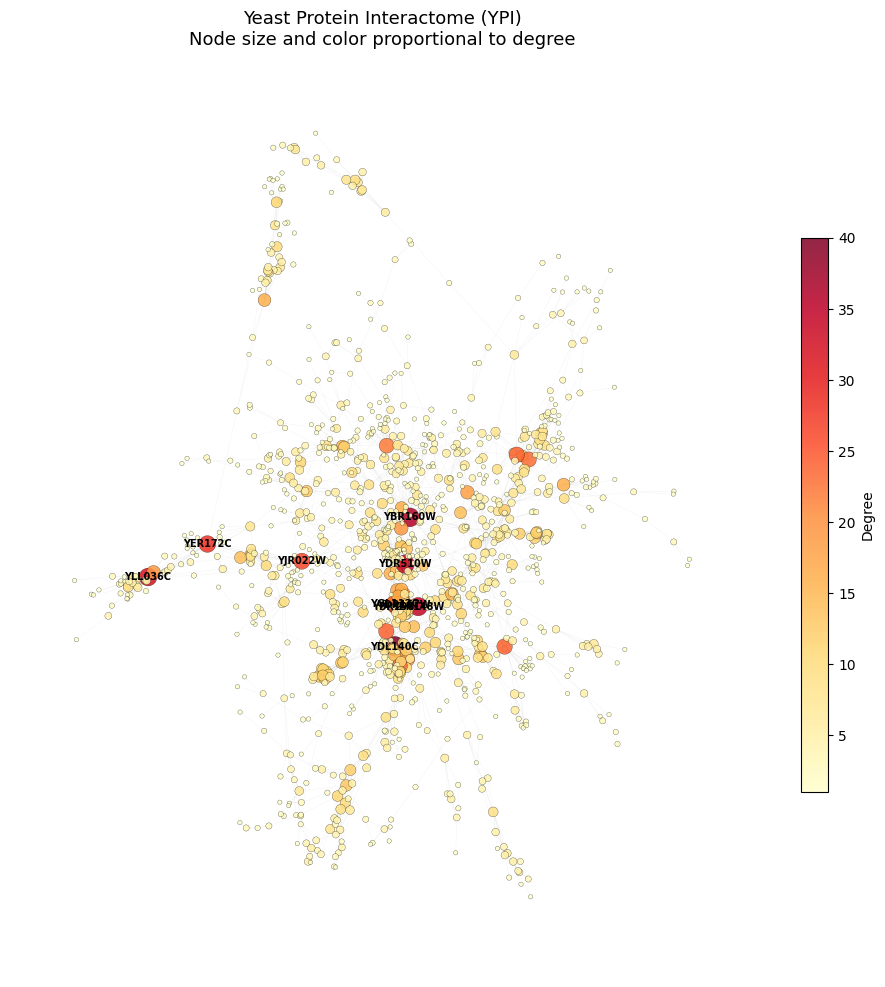


Top 10 proteins by degree (most interactions):
  YDL140C: degree = 40
  YBR160W: degree = 36
  YER148W: degree = 34
  YDR510W: degree = 34
  YLL036C: degree = 32
  YGL112C: degree = 28
  YER172C: degree = 28
  YJR022W: degree = 26
  YDR167W: degree = 25
  YBR198C: degree = 24


In [7]:
# Matplotlib visualization — node size proportional to degree
plt.figure(figsize=(12, 12))

# Spring layout
pos = nx.spring_layout(G_ypi, seed=42, k=0.3, iterations=50)

# Node sizes and colors based on degree
node_degrees = [G_ypi.degree(node) for node in G_ypi.nodes()]
node_sizes = [d * 5 + 5 for d in node_degrees]

# Draw edges
nx.draw_networkx_edges(G_ypi, pos, alpha=0.1, width=0.3, edge_color='gray')

# Draw nodes (color = degree)
nodes = nx.draw_networkx_nodes(G_ypi, pos, node_size=node_sizes,
                                node_color=node_degrees, cmap=plt.cm.YlOrRd,
                                alpha=0.85, edgecolors='k', linewidths=0.2)

# Label the top 10 highest-degree proteins
top_nodes = sorted(G_ypi.nodes(), key=lambda x: G_ypi.degree(x), reverse=True)[:10]
top_labels = {node: node for node in top_nodes}
nx.draw_networkx_labels(G_ypi, pos, top_labels, font_size=7, font_weight='bold')

plt.colorbar(nodes, label='Degree', shrink=0.6)
plt.title('Yeast Protein Interactome (YPI)\nNode size and color proportional to degree',
          fontsize=13)
plt.axis('off')
plt.savefig('ypi_network_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 proteins by degree (most interactions):")
for node in top_nodes:
    print(f"  {node}: degree = {G_ypi.degree(node)}")

---

## Part (b): Key Proteins and Essential Genes

We identify key proteins based on their number of interactions (degree) and cross-reference with essential gene data from the SGD Phenotype Database.

A gene is considered **essential** if its null mutant has an "inviable" phenotype — meaning the cell cannot survive without it.

In [8]:
# Load essential genes from SGD Phenotype_Data.tab
# Essential = null mutant with "inviable" phenotype
essential_genes = set()

with open('Phenotype_Data.tab', 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 10:
            orf_name = parts[0]       # systematic name (e.g., YJL001W)
            mutant_type = parts[6]    # null, conditional, etc.
            phenotype = parts[9]      # e.g., "inviable"
            
            if mutant_type.strip().lower() == 'null' and 'inviable' in phenotype.strip().lower():
                essential_genes.add(orf_name)

print(f"Total essential genes from SGD: {len(essential_genes)}")

# Cross-reference with YPI
ypi_proteins = set(G_ypi.nodes())
essential_in_ypi = essential_genes & ypi_proteins
nonessential_in_ypi = ypi_proteins - essential_genes

print(f"Proteins in YPI: {len(ypi_proteins)}")
print(f"Essential proteins in YPI: {len(essential_in_ypi)}")
print(f"Non-essential proteins in YPI: {len(nonessential_in_ypi)}")
print(f"Fraction essential: {len(essential_in_ypi)/len(ypi_proteins):.3f}")

Total essential genes from SGD: 1245
Proteins in YPI: 1213
Essential proteins in YPI: 568
Non-essential proteins in YPI: 645
Fraction essential: 0.468


In [9]:
# Key proteins — sorted by degree
proteins_by_degree = sorted(G_ypi.nodes(), key=lambda x: G_ypi.degree(x), reverse=True)

print("Top 20 proteins by number of interactions:")
print(f"{'Rank':<6} {'Protein':<12} {'Degree':<8} {'Essential?'}")
print("-" * 40)
for i, protein in enumerate(proteins_by_degree[:20]):
    is_ess = 'Yes' if protein in essential_genes else 'No'
    print(f"{i+1:<6} {protein:<12} {G_ypi.degree(protein):<8} {is_ess}")

Top 20 proteins by number of interactions:
Rank   Protein      Degree   Essential?
----------------------------------------
1      YDL140C      40       Yes
2      YBR160W      36       Yes
3      YER148W      34       Yes
4      YDR510W      34       Yes
5      YLL036C      32       Yes
6      YGL112C      28       Yes
7      YER172C      28       Yes
8      YJR022W      26       Yes
9      YDR167W      25       Yes
10     YBR198C      24       Yes
11     YER133W      24       Yes
12     YPL129W      24       No
13     YKL068W      24       No
14     YMR047C      23       Yes
15     YLR071C      23       Yes
16     YPL240C      22       Yes
17     YDR145W      22       Yes
18     YDR448W      21       No
19     YGR104C      19       No
20     YMR236W      19       Yes


### Fraction of Essential Proteins vs Degree

For each degree $k$, we compute what fraction of proteins with that degree are essential. According to Jeong et al. (Nature 2001), highly connected proteins are more likely to be essential.

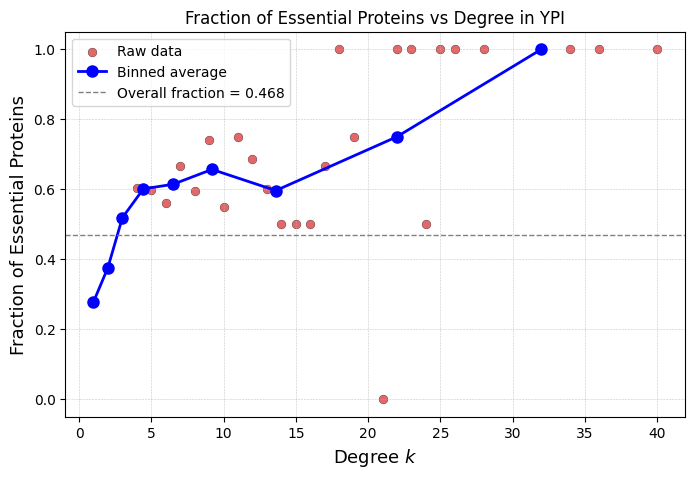

In [10]:
# Group proteins by degree and compute fraction essential
degree_groups = {}
for node in G_ypi.nodes():
    k = G_ypi.degree(node)
    if k not in degree_groups:
        degree_groups[k] = {'total': 0, 'essential': 0}
    degree_groups[k]['total'] += 1
    if node in essential_genes:
        degree_groups[k]['essential'] += 1

# To get smoother results, bin the degrees
# First plot raw data
k_vals_ess = sorted(degree_groups.keys())
frac_ess = [degree_groups[k]['essential'] / degree_groups[k]['total'] for k in k_vals_ess]

plt.figure(figsize=(8, 5))
plt.scatter(k_vals_ess, frac_ess, color='#d62728', alpha=0.7, s=40,
            edgecolors='k', linewidths=0.3, label='Raw data')

# Add a binned average (sliding window) for trend
# Bin into groups of roughly equal log-spacing
bin_edges = np.logspace(np.log10(max(min(k_vals_ess), 1)),
                        np.log10(max(k_vals_ess)), 10)
bin_k = []
bin_frac = []
for i in range(len(bin_edges) - 1):
    lo, hi = bin_edges[i], bin_edges[i+1]
    total_in_bin = 0
    essential_in_bin = 0
    k_sum = 0
    for k in k_vals_ess:
        if lo <= k < hi:
            total_in_bin += degree_groups[k]['total']
            essential_in_bin += degree_groups[k]['essential']
            k_sum += k * degree_groups[k]['total']
    if total_in_bin > 0:
        bin_k.append(k_sum / total_in_bin)
        bin_frac.append(essential_in_bin / total_in_bin)

plt.plot(bin_k, bin_frac, 'o-', color='blue', linewidth=2, markersize=8,
         label='Binned average')

# Overall fraction line
overall_frac = len(essential_in_ypi) / len(ypi_proteins)
plt.axhline(overall_frac, color='gray', linestyle='--', linewidth=1,
            label=f'Overall fraction = {overall_frac:.3f}')

plt.xlabel('Degree $k$', fontsize=13)
plt.ylabel('Fraction of Essential Proteins', fontsize=13)
plt.title('Fraction of Essential Proteins vs Degree in YPI', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
plt.savefig('ypi_essential_fraction_vs_degree.png', dpi=150, bbox_inches='tight')
plt.show()

Of the 1213 proteins in the YPI, 568 (46.8%) are essential. Among the top 20 highest-degree proteins, nearly all are essential — the top hub (YDL140C, degree 40) is essential, and so are the next 9 hubs in the ranking. The plot shows the fraction of essential proteins rising with degree, especially once $k$ exceeds the network average (~4). This is the centrality-lethality rule from Jeong et al. (Nature 2001): hub proteins are harder to replace because they're involved in more pathways.

---

## Part (c): Robustness Analysis — Random and Targeted Deletion

Following the same approach as Q4, we apply random failure and targeted attack to the YPI and track:
- $S$: giant cluster size (normalized)
- $\langle s \rangle$: average size of non-giant components

In [11]:
# Robustness helper functions (same as Q4)

def compute_S(G, n0):
    """Giant cluster size normalized by original n."""
    if G.number_of_nodes() == 0:
        return 0.0
    components = list(nx.connected_components(G))
    return max(len(c) for c in components) / n0


def compute_avg_small_s(G):
    """Average size of non-giant components."""
    if G.number_of_nodes() == 0:
        return 0.0
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    if len(components) <= 1:
        return 0.0
    small_sizes = [len(c) for c in components[1:]]
    return np.mean(small_sizes)


def simulate_deletion(G, strategy='random', f_steps=None):
    """
    Progressively delete nodes and record S and <s>.
    strategy: 'random' or 'targeted' (highest degree first)
    """
    if f_steps is None:
        f_steps = np.arange(0.0, 0.81, 0.04)

    G_curr = G.copy()
    n0 = G.number_of_nodes()

    if strategy == 'targeted':
        removal_order = sorted(G.nodes(), key=lambda v: G.degree(v), reverse=True)
    else:
        removal_order = list(G.nodes())
        random.shuffle(removal_order)

    results_f = []
    results_S = []
    results_s = []
    removed_so_far = 0

    for f in f_steps:
        target_removed = int(f * n0)
        while removed_so_far < target_removed and removed_so_far < len(removal_order):
            node = removal_order[removed_so_far]
            if G_curr.has_node(node):
                G_curr.remove_node(node)
            removed_so_far += 1

        results_f.append(f)
        results_S.append(compute_S(G_curr, n0))
        results_s.append(compute_avg_small_s(G_curr))

    return {
        'f': np.array(results_f),
        'S': np.array(results_S),
        's_avg': np.array(results_s)
    }

In [12]:
f_steps = np.arange(0.0, 0.81, 0.04)

print("Running random failure on YPI...")
res_random = simulate_deletion(G_ypi, strategy='random', f_steps=f_steps)

print("Running targeted attack on YPI...")
res_targeted = simulate_deletion(G_ypi, strategy='targeted', f_steps=f_steps)

print("Done.")

Running random failure on YPI...
Running targeted attack on YPI...
Done.


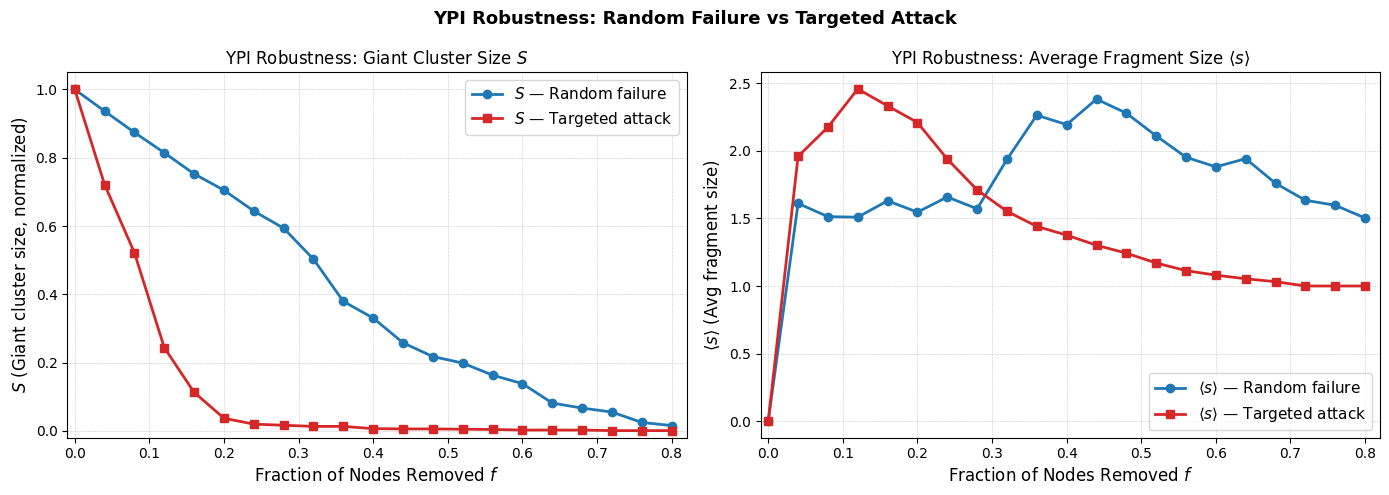

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# S plot
axes[0].plot(res_random['f'], res_random['S'],
             'o-', color='#1f77b4', linewidth=2, markersize=6, label='$S$ — Random failure')
axes[0].plot(res_targeted['f'], res_targeted['S'],
             's-', color='#d62728', linewidth=2, markersize=6, label='$S$ — Targeted attack')
axes[0].set_xlabel('Fraction of Nodes Removed $f$', fontsize=12)
axes[0].set_ylabel('$S$ (Giant cluster size, normalized)', fontsize=12)
axes[0].set_title('YPI Robustness: Giant Cluster Size $S$', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
axes[0].set_xlim(-0.01, 0.82)
axes[0].set_ylim(-0.02, 1.05)

# <s> plot
axes[1].plot(res_random['f'], res_random['s_avg'],
             'o-', color='#1f77b4', linewidth=2, markersize=6, label='$\\langle s \\rangle$ — Random failure')
axes[1].plot(res_targeted['f'], res_targeted['s_avg'],
             's-', color='#d62728', linewidth=2, markersize=6, label='$\\langle s \\rangle$ — Targeted attack')
axes[1].set_xlabel('Fraction of Nodes Removed $f$', fontsize=12)
axes[1].set_ylabel('$\\langle s \\rangle$ (Avg fragment size)', fontsize=12)
axes[1].set_title('YPI Robustness: Average Fragment Size $\\langle s \\rangle$', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
axes[1].set_xlim(-0.01, 0.82)

plt.suptitle('YPI Robustness: Random Failure vs Targeted Attack', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ypi_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

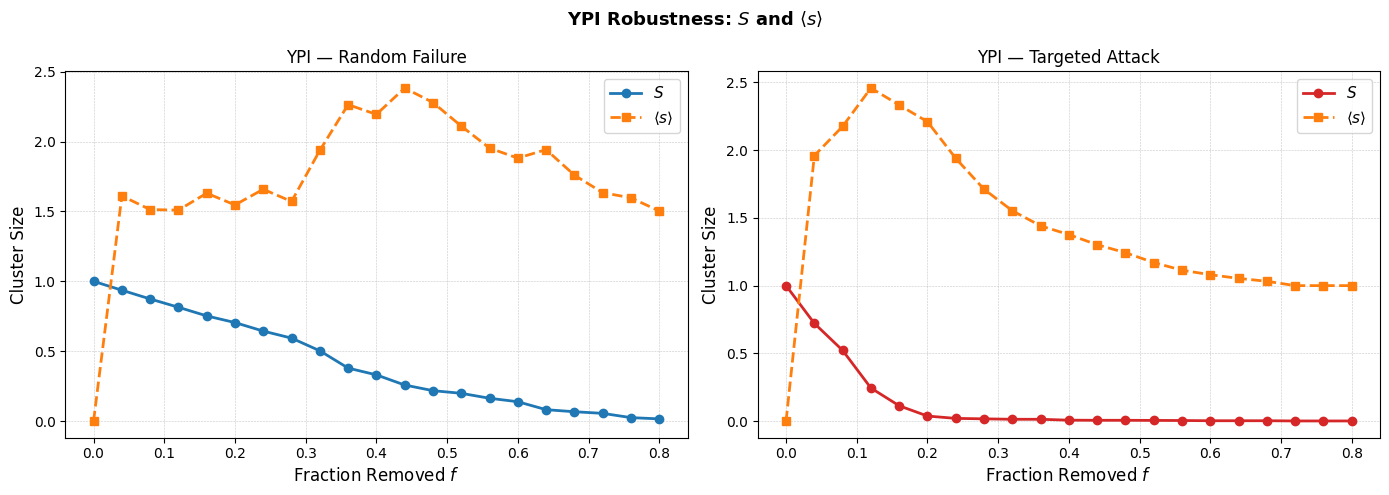

In [14]:
# Combined S and <s> on same plot for each strategy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random failure
axes[0].plot(res_random['f'], res_random['S'],
             'o-', color='#1f77b4', linewidth=2, markersize=6, label='$S$')
axes[0].plot(res_random['f'], res_random['s_avg'],
             's--', color='#ff7f0e', linewidth=2, markersize=6, label='$\\langle s \\rangle$')
axes[0].set_xlabel('Fraction Removed $f$', fontsize=12)
axes[0].set_ylabel('Cluster Size', fontsize=12)
axes[0].set_title('YPI — Random Failure', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', linewidth=0.4, alpha=0.7)

# Targeted attack
axes[1].plot(res_targeted['f'], res_targeted['S'],
             'o-', color='#d62728', linewidth=2, markersize=6, label='$S$')
axes[1].plot(res_targeted['f'], res_targeted['s_avg'],
             's--', color='#ff7f0e', linewidth=2, markersize=6, label='$\\langle s \\rangle$')
axes[1].set_xlabel('Fraction Removed $f$', fontsize=12)
axes[1].set_ylabel('Cluster Size', fontsize=12)
axes[1].set_title('YPI — Targeted Attack', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', linewidth=0.4, alpha=0.7)

plt.suptitle('YPI Robustness: $S$ and $\\langle s \\rangle$', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ypi_robustness_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## Observations

**Part (a):** The YPI has 1213 proteins and 2556 interactions (average degree 4.21, max degree 40). The degree distribution is heavy-tailed on the log-log plot — most proteins have just 1–3 interactions while a few hubs like YDL140C (degree 40), YBR160W (36), and YER148W (34) are highly connected. The $C(k) \times k$ plot shows that low-degree proteins tend to cluster in tight local modules while high-degree hubs bridge between them with lower local clustering.

**Part (b):** 568 out of 1213 proteins (46.8%) are essential. The fraction of essential proteins increases with degree — the top 10 hubs are all essential. This is the centrality-lethality rule (Jeong et al., 2001): if you delete a hub protein, many pathways break simultaneously, which is lethal.

**Part (c):** The YPI shows the same robustness pattern as other scale-free networks:
- **Random failure:** $S$ drops slowly — most randomly removed proteins are peripheral and not critical to connectivity.
- **Targeted attack:** $S$ drops much faster — removing the highest-degree hubs quickly fragments the network.
- $\langle s \rangle$ peaks near the percolation threshold under targeted attack, showing the network breaks into many small pieces.

This ties Parts (b) and (c) together: the hub proteins that are structurally important (high degree) are exactly the ones that are also biologically essential.